In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from itertools import product
import pandas as pd
import os


sns.set_theme()
sns.set_context("paper")

# This block contains a lot of functions that are commonly needed.
def write_fig(fname: str, plot):
    fig = plot.get_figure()
    dst = os.path.join("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots", f"{fname}.svg")
    fig.savefig(dst)

def add_name_device(df: pd.DataFrame, benchmark_name: str, device: str):
    df["benchmark_name"] = benchmark_name
    df["device"] = device
    return df

The following block is used to produce the chars for Amdahl's law an and Gustavson's Law

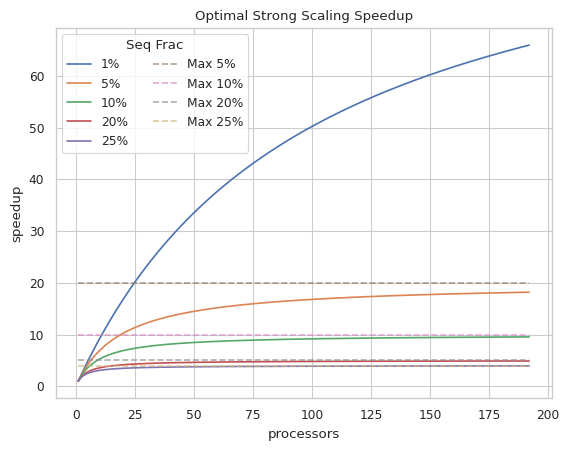

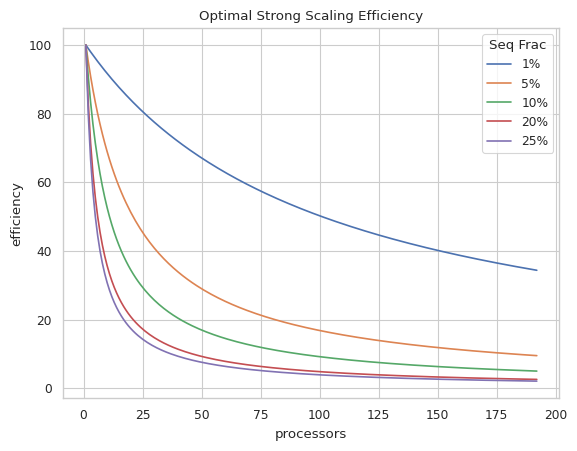

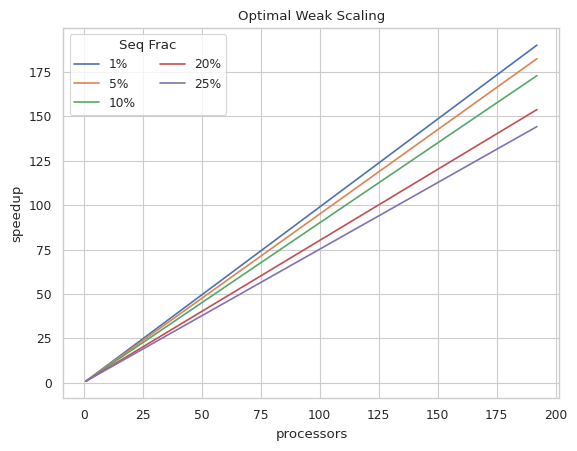

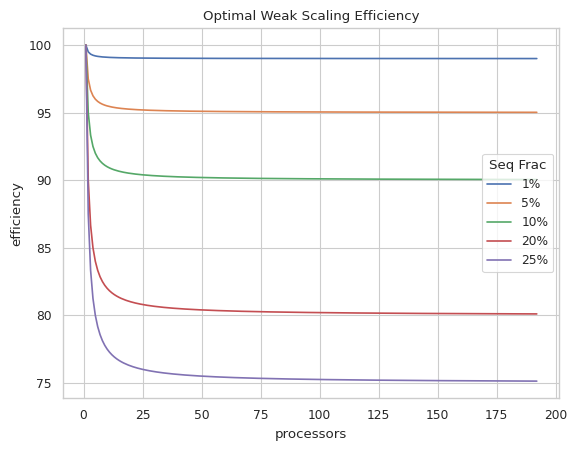

In [95]:
max_proc = 192
seq_part = [0.01, 0.05, 0.1, 0.2, 0.25]
processors = [i+1 for i in range(max_proc)]

def amdahl(s, n):
    p = 1 - s
    return 1 / (s + (p / n))

def gustavson(s, n):
    p = 1 - s
    return s + n * p

a_speedup = list(map(lambda x : {"fraction": str(int(x[0] * 100)) + "%",
                                 "processors": x[1],
                                 "speedup": amdahl(x[0], x[1])}, product(seq_part, processors)))

a_efficiency = list(map(lambda x : {"fraction": str(int(x[0] * 100)) + "%",
                                    "processors": x[1],
                                    "efficiency": (amdahl(x[0], x[1]) / x[1]) * 100}, product(seq_part, processors)))

g_speedup = list(map(lambda x : {"fraction": str(int(x[0] * 100)) + "%",
                                 "processors": x[1],
                                 "speedup": gustavson(x[0], x[1])}, product(seq_part, processors)))

g_efficiency = list(map(lambda x : {"fraction": str(int(x[0] * 100)) + "%",
                                    "processors": x[1],
                                    "efficiency": (gustavson(x[0], x[1]) / x[1]) * 100}, product(seq_part, processors)))

a_proc_df = pd.DataFrame.from_dict(a_speedup)
a_eff_df = pd.DataFrame.from_dict(a_efficiency)

g_proc_df = pd.DataFrame.from_dict(g_speedup)
g_eff_df = pd.DataFrame.from_dict(g_efficiency)

with sns.axes_style("whitegrid"):
    # lp = sns.lineplot(x=processors, y=processors, label="0% - ideal")
    lp = sns.lineplot(data=a_proc_df, x="processors", y="speedup", hue="fraction")

    # Add asymptotes
    for s in seq_part[1:]:
        sns.lineplot(x=processors, y=[1/s] * max_proc, legend=True, alpha=0.7, linestyle="--", label=f"Max {str(int(s*100))}%")

    plt.legend(title="Seq Frac")
    plt.title("Optimal Strong Scaling Speedup")
    # sns.move_legend(lp, loc="upper left", ncol=2, bbox_to_anchor=(1,1))
    sns.move_legend(lp, loc="upper left", ncol=2)

    write_fig("00_amdal_speedup", lp)
plt.show()

with sns.axes_style("whitegrid"):
    lp = sns.lineplot(data=a_eff_df, x="processors", y="efficiency", hue="fraction", )

    plt.title("Optimal Strong Scaling Efficiency")
    plt.legend(title="Seq Frac")

    write_fig("01_amdal_efficiency", lp)
plt.show()

with sns.axes_style("whitegrid"):
    # lp = sns.lineplot(x=processors, y=processors, label="0% - ideal")
    lp = sns.lineplot(data=g_proc_df, x="processors", y="speedup", hue="fraction")

    # Add asymptotes
    # for s in seq_part[1:]:
    #     sns.lineplot(x=processors, y=[1/s] * max_proc, legend=True, alpha=0.7, linestyle="--", label=f"Max {str(int(s*100))}%")

    plt.legend(title="Seq Frac")
    plt.title("Optimal Weak Scaling")
    # sns.move_legend(lp, loc="upper left", ncol=2, bbox_to_anchor=(1,1))
    sns.move_legend(lp, loc="upper left", ncol=2)

    write_fig("02_gustavson_speedup", lp)
plt.show()

with sns.axes_style("whitegrid"):
    lp = sns.lineplot(data=g_eff_df, x="processors", y="efficiency", hue="fraction", )

    plt.title("Optimal Weak Scaling Efficiency")
    plt.legend(title="Seq Frac")

    # Asymptots are obvious enough.
    # for s in seq_part:
    #     sns.lineplot(x=processors, y=[100*(1-s)] * max_proc, legend=True, alpha=0.7, linestyle="--", label=f"Max {str(int(s*100))}%")

    write_fig("03_gustavson_efficiency", lp)
plt.show()



Generate Dimension Input for Benchmarks

In [96]:
print("CPU Small")
print(" ".join([str(int(2 ** (0.5 * i))) for i in range(12, 19)]))
print()

print("CPU Medium")
print(" ".join([str(int(2 ** (0.5 * i))) for i in range(18, 25)]))
print()

print("CPU Large")
print(" ".join([str(int(2 ** (0.5 * i))) for i in range(24, 29)]))
print()

print("GPU PC")
print(" ".join([str(int(2 ** (0.5 * i))) for i in range(12, 25)]))
print()

print("GPU Cluster")
print(" ".join([str(int(2 ** (0.5 * i))) for i in range(12, 31)]))
print()

print("Cache Samples")
print(" ".join([str(i) for i in range(16, 1536, 16)]))
print()

print(f"Cache B Samples")
print(" ".join([str(i) for i in range(16, 129, 8)]))
print()

CPU Small
64 90 128 181 256 362 512

CPU Medium
512 724 1024 1448 2048 2896 4096

CPU Large
4096 5792 8192 11585 16384

GPU PC
64 90 128 181 256 362 512 724 1024 1448 2048 2896 4096

GPU Cluster
64 90 128 181 256 362 512 724 1024 1448 2048 2896 4096 5792 8192 11585 16384 23170 32768

Cache Samples
16 32 48 64 80 96 112 128 144 160 176 192 208 224 240 256 272 288 304 320 336 352 368 384 400 416 432 448 464 480 496 512 528 544 560 576 592 608 624 640 656 672 688 704 720 736 752 768 784 800 816 832 848 864 880 896 912 928 944 960 976 992 1008 1024 1040 1056 1072 1088 1104 1120 1136 1152 1168 1184 1200 1216 1232 1248 1264 1280 1296 1312 1328 1344 1360 1376 1392 1408 1424 1440 1456 1472 1488 1504 1520

Cache B Samples
16 24 32 40 48 56 64 72 80 88 96 104 112 120 128



Plot to visualize the difference between ram and pci-e bandwidth

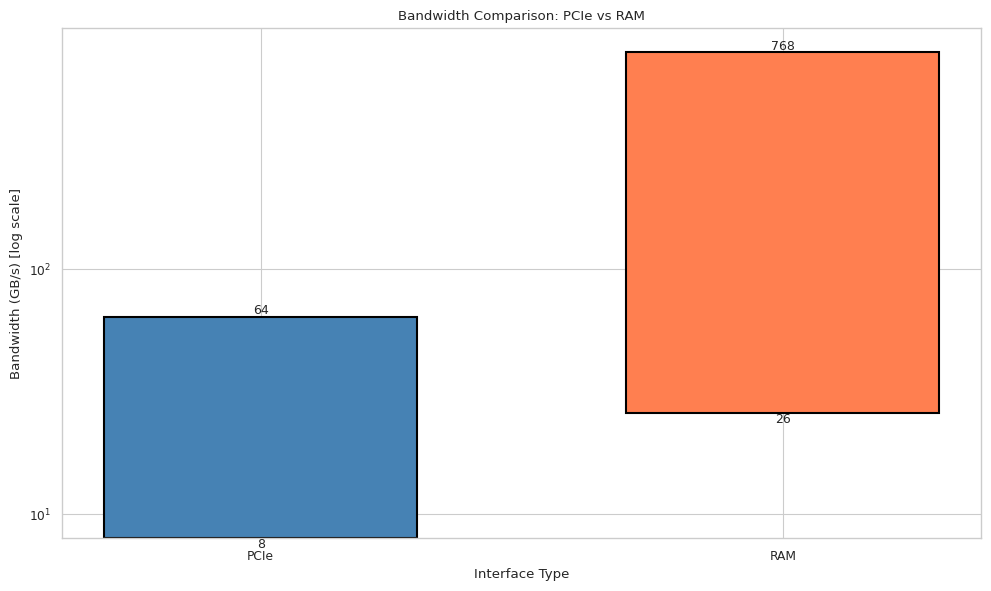

In [97]:
summary_data = {
    'Interface': ['PCIe', 'RAM'],
    'Min': [8, 26],
    'Max': [64, 768]
}

summary_df = pd.DataFrame(summary_data)
sns.set_context("paper")

with sns.axes_style("whitegrid"):
    fig = plt.figure(figsize=(10, 6))

    # Create bars from min to max
    for i, row in summary_df.iterrows():
        plt.bar(i, row['Max'] - row['Min'],
                bottom=row['Min'],
                width=0.6,
                color=['steelblue', 'coral'][i],
                edgecolor='black',
                linewidth=1.5)

    plt.yscale('log')
    plt.xticks([0, 1], summary_df['Interface'])
    plt.ylabel('Bandwidth (GB/s) [log scale]')
    plt.xlabel('Interface Type')
    plt.title('Bandwidth Comparison: PCIe vs RAM')

    # Add min/max labels
    for i, row in summary_df.iterrows():
        plt.text(i, row['Min'], f"{row['Min']}",
                ha='center', va='top', fontsize=9)
        plt.text(i, row['Max'], f"{row['Max']}",
                ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    write_fig("04_bandwidth-delta", fig)
    plt.show()


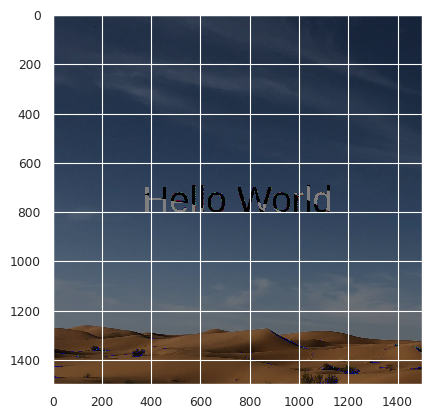

In [98]:
# Picture Merge
from PIL import Image
import numpy as np

desert_pil = Image.open("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots/zebera/pexels-greg-gulik-349419-1001435.jpg")
zebra_pil = Image.open("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots/zebera/Zebra_print_2.jpg")
text_pil = Image.open("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots/zebera/text.png")


white = np.full((1500, 1500, 3), 255, dtype=np.uint8)
desert_np = np.array(desert_pil)[:1500, :1500,:]
zebra_np = np.array(zebra_pil)[:,:,:1]
text_np = np.array(text_pil)[:,:,:1]

text_over_desert = desert_np.copy()
plt.imshow(desert_np, interpolation="nearest")

out_simple = white - (text_over_desert * text_np) + (white - text_np)
out_complex_fp = (white - (text_over_desert * text_np) + (white - zebra_np) * (white - text_np)) / 2
out_complex = out_complex_fp.astype(np.uint8)

img = Image.fromarray(out_simple)
img.save("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots/zebera/simple.png")

img2 = Image.fromarray(out_complex)
img2.save("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots/zebera/complex.png")

img3 = Image.fromarray(desert_np)
img3.save("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots/zebera/desert_crop.png")

img4 = Image.fromarray(white - text_np)
img4.save("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots/zebera/text_inverted.png")

img5 = Image.fromarray(white - zebra_np)
img5.save("/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/plots/zebera/zebra_inverted.png")


# plt.imshow(out_simple, interpolation="nearest")
plt.imshow(out_complex, interpolation="nearest")


Index(['cpu_count', 'module', 'benchmark_type', 'max_iter', 'nx', 'ny',
       'cache_bs_1', 'cache_bs_2', 'iter_unrol', 'sample', 'duration',
       'normalized_duration', 'name', 'benchmark_name', 'device',
       'group-cpu-nx-ny', 'group-module-nx-ny', 'dim', 'group-module-cpu'],
      dtype='object')


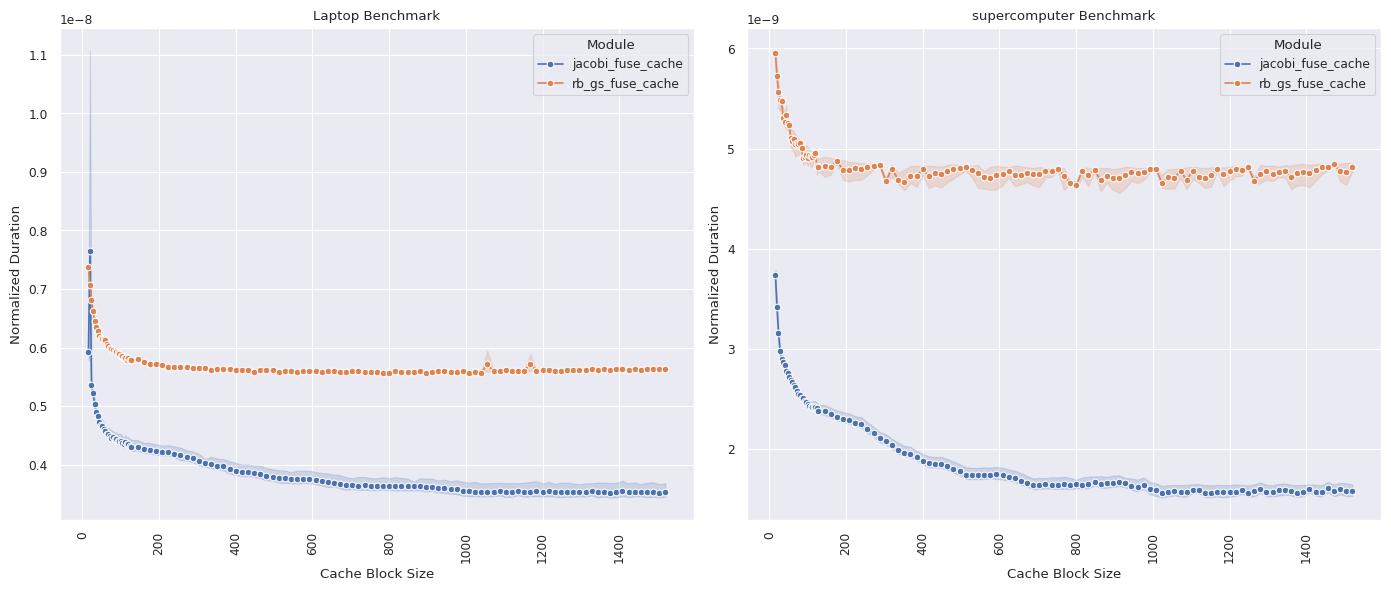

In [99]:
from benchmark import results_processing as rp

laptop_cache = [
    "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/caching_1/laptop/pcbm_20251127-210820_KZLN37DcdxasRrNFAXuIFlAfd7JsxbDXD7iXi0hPxdA=.json",
    "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/caching_1/laptop/pcbm_20251128-053237_txfW8CXpowin3L_35_o13fiI52bn0j620XVdmi3qTek=.json"
]

supercomputer_cache = [
    "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/caching_1/piora/pcbm_20251127-144737_jyUj7KY1q_dp-POLlhXbcuq4x3oCcgoYnbH0zbWd7gk=.json",
    "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/caching_1/piora/pcbm_20251127-204632_JlFhB5nK2w5HZx-pWIhcDndJgiSmMeJ6_DIthOGaBL8=.json"
]

laptop_caches = pd.concat(list(map(lambda p : rp.create_dataframe(rp.load_benchmark_run(p)), laptop_cache)), ignore_index=True)
supercomputer_caches = pd.concat(list(map(lambda p : rp.create_dataframe(rp.load_benchmark_run(p)), supercomputer_cache)), ignore_index=True)


fully_augmented = rp.augment_df(pd.concat([add_name_device(df=laptop_caches,
                                                           device="cpu",
                                                           benchmark_name="laptop"),
                                           add_name_device(df=supercomputer_caches,
                                                           device="cpu",
                                                           benchmark_name="supercomputer")], ignore_index=True))

print(fully_augmented.columns)

# Create Dual Plot for Pandas
# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First plot: laptop data
laptop_data1 = fully_augmented[fully_augmented['benchmark_name'] == 'laptop']
laptop_data =  laptop_data1[laptop_data1['module'] != "jacobi_fuse_cache_unroll_jitter"]
sns.lineplot(data=laptop_data, x='cache_bs_1', y='normalized_duration',
             hue='module', marker='o', ax=axes[0])
axes[0].set_title('Laptop Benchmark')
axes[0].set_xlabel('Cache Block Size')
axes[0].set_ylabel('Normalized Duration')
axes[0].tick_params(axis='x', rotation=90)
axes[0].legend(title='Module')

# Second plot: supercomputer data
supercomputer_data1 = fully_augmented[fully_augmented['benchmark_name'] == 'supercomputer']
supercomputer_data = supercomputer_data1[supercomputer_data1["module"] != "jacobi_fuse_cache_unroll_jitter"]
sns.lineplot(data=supercomputer_data, x='cache_bs_1', y='normalized_duration',
             hue='module', marker='o', ax=axes[1])
axes[1].set_title('supercomputer Benchmark')
axes[1].set_xlabel('Cache Block Size')
axes[1].set_ylabel('Normalized Duration')
axes[1].tick_params(axis='x', rotation=90)
axes[1].legend(title='Module')

plt.tight_layout()
plt.show()


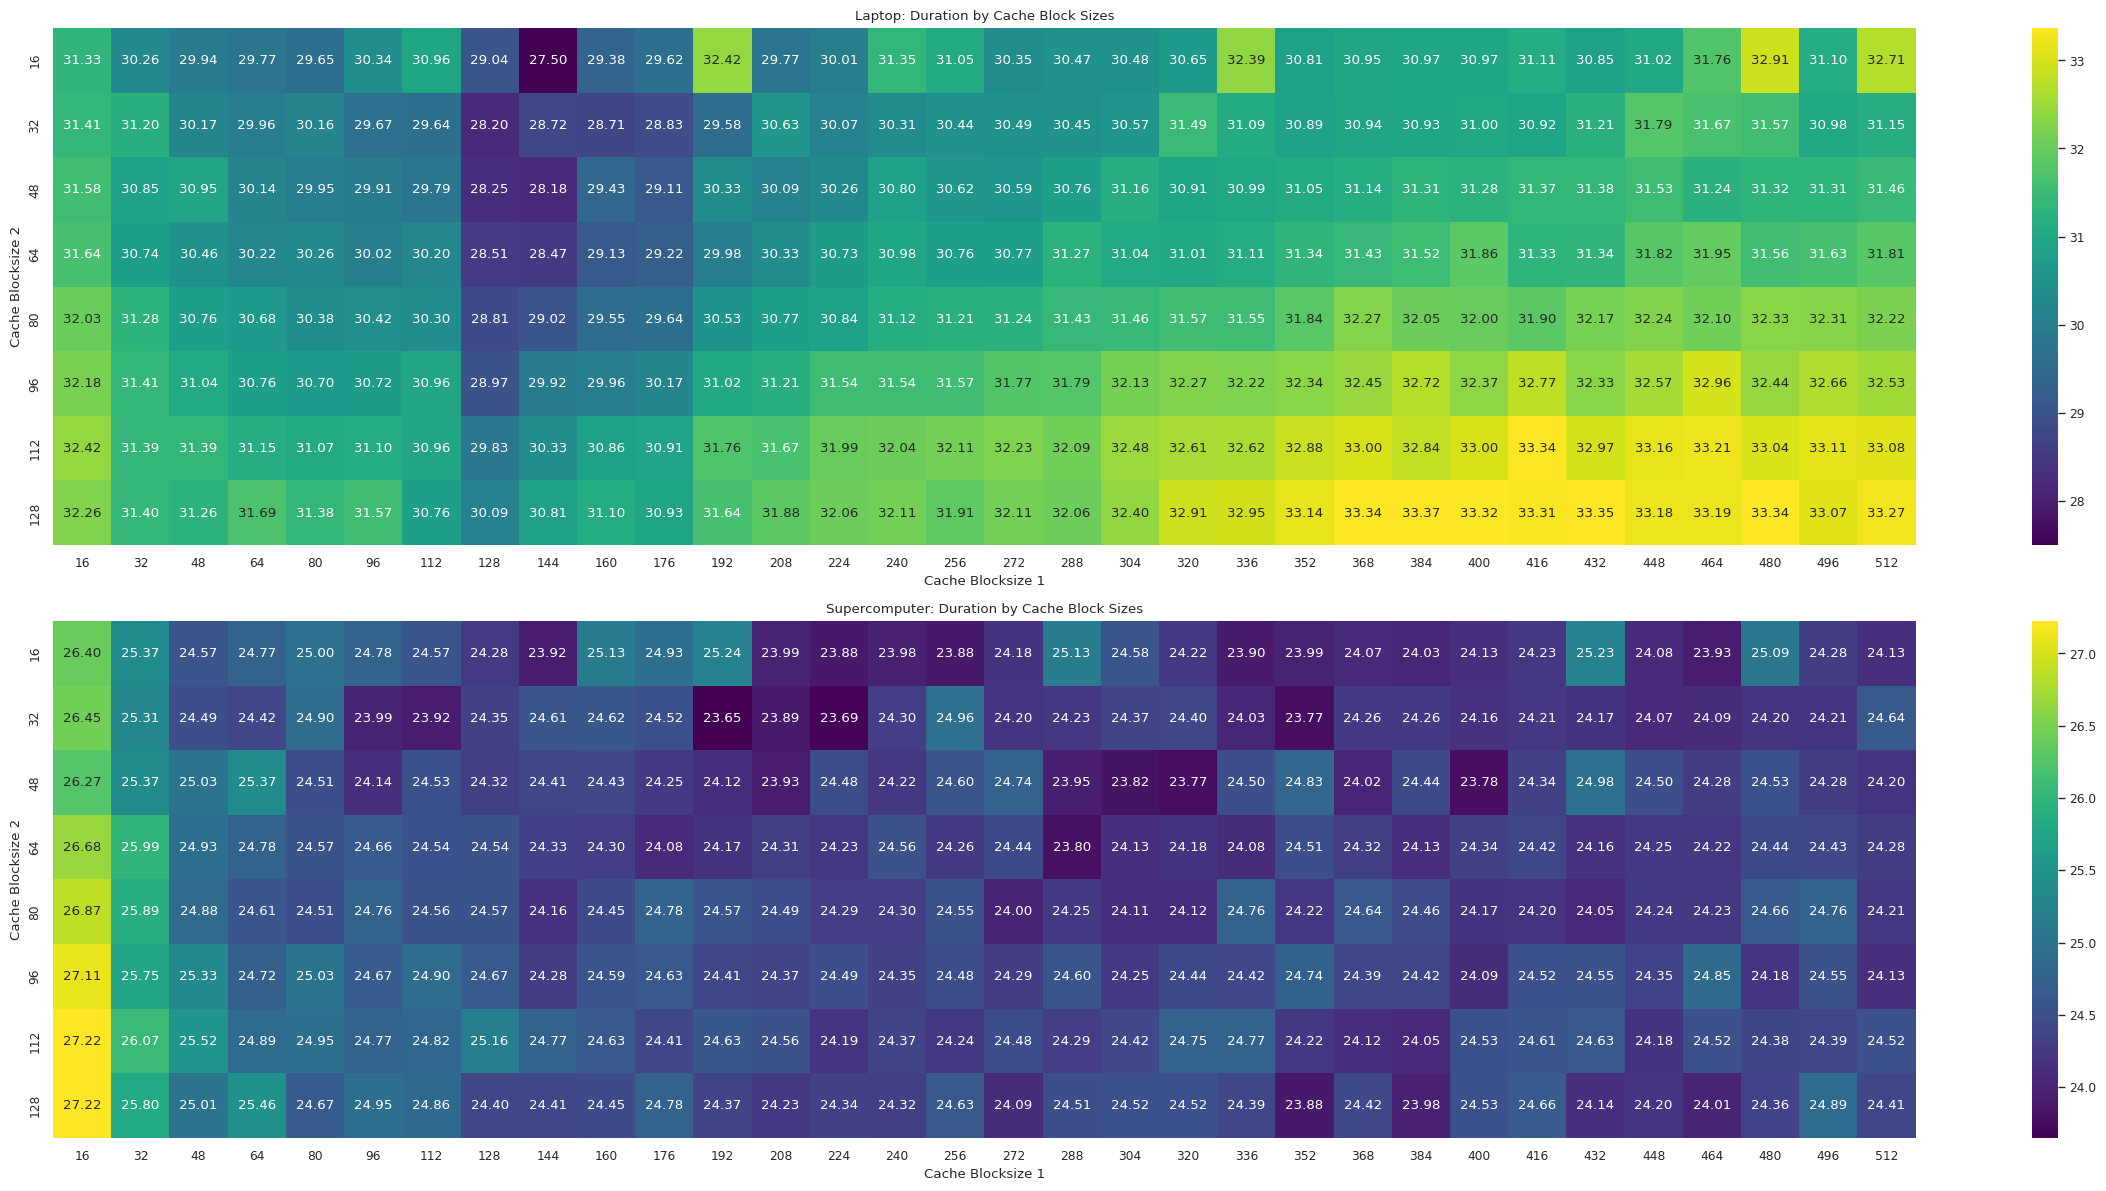

In [100]:
# Filter data for the specific module
data_2d = fully_augmented[fully_augmented['module'] == "jacobi_fuse_cache_unroll_jitter"]

with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(2, 1, figsize=(24, 12))

    # First heatmap: laptop
    laptop_data = data_2d[data_2d["benchmark_name"] == "laptop"]
    heatmap_laptop = laptop_data.pivot_table(index='cache_bs_2',
                                              columns='cache_bs_1',
                                              values='duration',
                                              aggfunc='mean')

    sns.heatmap(heatmap_laptop, annot=True, fmt='.2f', cmap='viridis', ax=axes[0])
    axes[0].set_title('Laptop: Duration by Cache Block Sizes')
    axes[0].set_xlabel('Cache Blocksize 1')
    axes[0].set_ylabel('Cache Blocksize 2')

    # Second heatmap: supercomputer
    supercomputer_data = data_2d[data_2d["benchmark_name"] == "supercomputer"]
    heatmap_supercomputer = supercomputer_data.pivot_table(index='cache_bs_2',
                                                            columns='cache_bs_1',
                                                            values='duration',
                                                            aggfunc='mean')

    sns.heatmap(heatmap_supercomputer, annot=True, fmt='.2f', cmap='viridis', ax=axes[1])
    axes[1].set_title('Supercomputer: Duration by Cache Block Sizes')
    axes[1].set_xlabel('Cache Blocksize 1')
    axes[1].set_ylabel('Cache Blocksize 2')

    plt.tight_layout()
    plt.show()

Scaling Benchmarks Preparation

In [101]:
import os
from benchmark import results_processing as rp
cpu_laptop = ["/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_1/laptop/pcbm_20251127-153037_MHgUgPYt5tCihLSqLL9nSZXNz7ZZjQFh-Nsa7KOYkNc=.json",
              "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_1/laptop/pcbm_20251127-153332_mZeAvqVX_O53jIPeJwqdT0bPl-ZXYsr90tQsn7dIzwI=.json",
              "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_1/laptop/pcbm_20251127-154324_EPLYGVELhXVYFo9EM7_U9pf7L3WJsHQ1pIqAMK2Uy6Y=.json"]
gpu_laptop = ["/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_1/laptop/pcbm_20251127-160010_NEK8oOQ2-XLdzomJbC39wxfFEHOBTt5M2lgYJWyGbI4=.json",
              "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_1/laptop/pcbm_20251127-160135_5j6SaODlr0CSo7Ls-YaYC8WG7CTpURBFLMS3VUu8SAM=.json",
              "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_1/laptop/pcbm_20251127-160300_1u3NWcwX6rP1ApkMruK4vB73joxtuL_0t0J14cqkm5Q=.json"]
cpu_supercomputer = ["/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_2/piora/pcbm_20251128-190713_gWp4hM0od0AieTmlmzMmu0mhkiJ-dzcELCLlPGpyOtA=.json",
                     "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_2/piora/pcbm_20251128-191131_cFRaoY9dQXBptctF5ytNHypsJxSs_UmU3bgueEJpCZg=.json",
                     "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_2/piora/pcbm_20251128-192303_dzsgPNqfP0ZXwyMNv43zm9LaCLcFs6xj0r4mg-St3Pk=.json"]
gpu_supercomputer = ["/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_2/piora/pcbm_20251128-200811_-earz9NvDQ3cz_sOjgWdvsMYHb1eqtfVoewINkbHuU0=.json",
                     "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_2/piora/pcbm_20251128-200934_-yinb2qMe4CWTs9eF7C2BHNtJ3mB0t5dcxL4REF72BY=.json",
                     "/home/alisot2000/Documents/02_ETH/Bachelor_Thesis/Pyroclast/scripts/thesis/benchmark_results_copy/scaling_2/piora/pcbm_20251128-201042_TsUiuPR7slc9rPaFpfrf_69sRQs14ort7A_gok6M85M=.json"]

cpu_small_laptop, cpu_medium_laptop, cpu_large_laptop = list(map(lambda p: rp.create_dataframe(rp.load_benchmark_run(path=p)), cpu_laptop))
gpu_small_laptop, gpu_medium_laptop, gpu_large_laptop = list(map(lambda p: rp.create_dataframe(rp.load_benchmark_run(path=p)), gpu_laptop))
cpu_small_supercomputer, cpu_medium_supercomputer, cpu_large_supercomputer = list(map(lambda p: rp.create_dataframe(rp.load_benchmark_run(path=p)), cpu_supercomputer))
gpu_small_supercomputer, gpu_medium_supercomputer, gpu_large_supercomputer = list(map(lambda p: rp.create_dataframe(rp.load_benchmark_run(path=p)), gpu_supercomputer))

# Add columns for easier identification
cpu_small_laptop = add_name_device(cpu_small_laptop, benchmark_name="cpu_small_laptop", device="cpu")
cpu_medium_laptop = add_name_device(cpu_medium_laptop, benchmark_name="cpu_medium_laptop", device="cpu")
cpu_large_laptop = add_name_device(cpu_large_laptop, benchmark_name="cpu_large_laptop", device="cpu")

gpu_small_laptop = add_name_device(gpu_small_laptop, benchmark_name="gpu_small_laptop", device="gpu")
gpu_medium_laptop = add_name_device(gpu_medium_laptop, benchmark_name="gpu_medium_laptop", device="gpu")
gpu_large_laptop = add_name_device(gpu_large_laptop, benchmark_name="gpu_large_laptop", device="gpu")

laptop_scaling = pd.concat([cpu_small_laptop, cpu_medium_laptop, cpu_large_laptop, gpu_small_laptop,  gpu_medium_laptop, gpu_large_laptop], ignore_index=True)
laptop_scaling = rp.augment_df(laptop_scaling)

# Here the issue seems to take hold
cpu_small_supercomputer = add_name_device(cpu_small_supercomputer, benchmark_name="cpu_small_supercomputer", device="cpu")
cpu_medium_supercomputer = add_name_device(cpu_medium_supercomputer, benchmark_name="cpu_medium_supercomputer", device="cpu")
cpu_large_supercomputer = add_name_device(cpu_large_supercomputer, benchmark_name="cpu_large_supercomputer", device="cpu")

gpu_small_supercomputer = add_name_device(gpu_small_supercomputer, benchmark_name="gpu_small_supercomputer", device="gpu")
gpu_medium_supercomputer = add_name_device(gpu_medium_supercomputer, benchmark_name="gpu_medium_supercomputer", device="gpu")
gpu_large_supercomputer = add_name_device(gpu_large_supercomputer, benchmark_name="gpu_large_supercomputer", device="gpu")

supercomputer_scaling = pd.concat([cpu_small_supercomputer, cpu_medium_supercomputer, cpu_large_supercomputer, gpu_small_supercomputer,  gpu_medium_supercomputer, gpu_large_supercomputer], ignore_index=True)
supercomputer_scaling = rp.augment_df(supercomputer_scaling)


joint_df = pd.concat([laptop_scaling, supercomputer_scaling], ignore_index=True)

print(joint_df.columns)

/tmp/ipykernel_12826/459062145.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  laptop_scaling = pd.concat([cpu_small_laptop, cpu_medium_laptop, cpu_large_laptop, gpu_small_laptop,  gpu_medium_laptop, gpu_large_laptop], ignore_index=True)
/tmp/ipykernel_12826/459062145.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  supercomputer_scaling = pd.concat([cpu_small_supercomputer, cpu_medium_supercomputer, cpu_large_supercomputer, gpu_small_supercomputer,  gpu_medium_supercomputer, gpu_large_

Index(['cpu_count', 'module', 'benchmark_type', 'max_iter', 'nx', 'ny',
       'cache_bs_1', 'cache_bs_2', 'iter_unrol', 'sample', 'duration',
       'normalized_duration', 'name', 'benchmark_name', 'device',
       'group-cpu-nx-ny', 'group-module-nx-ny', 'dim', 'group-module-cpu'],
      dtype='object')


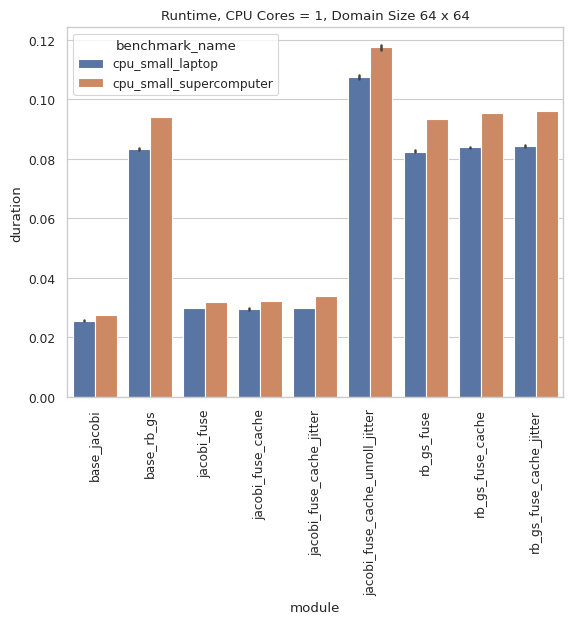

In [102]:
# Plot for algorithmic efficiency.
algo_eff_dataframe = joint_df.query("nx == 64 and ny == 64 and device == 'cpu' and cpu_count == 1")


with sns.axes_style("whitegrid"):
    # ax = plt.axes()
    plt.xticks(rotation=90)
    sns.barplot(data=algo_eff_dataframe, x="module", y="duration", hue="benchmark_name")
    plt.title("Runtime, CPU Cores = 1, Domain Size 64 x 64")



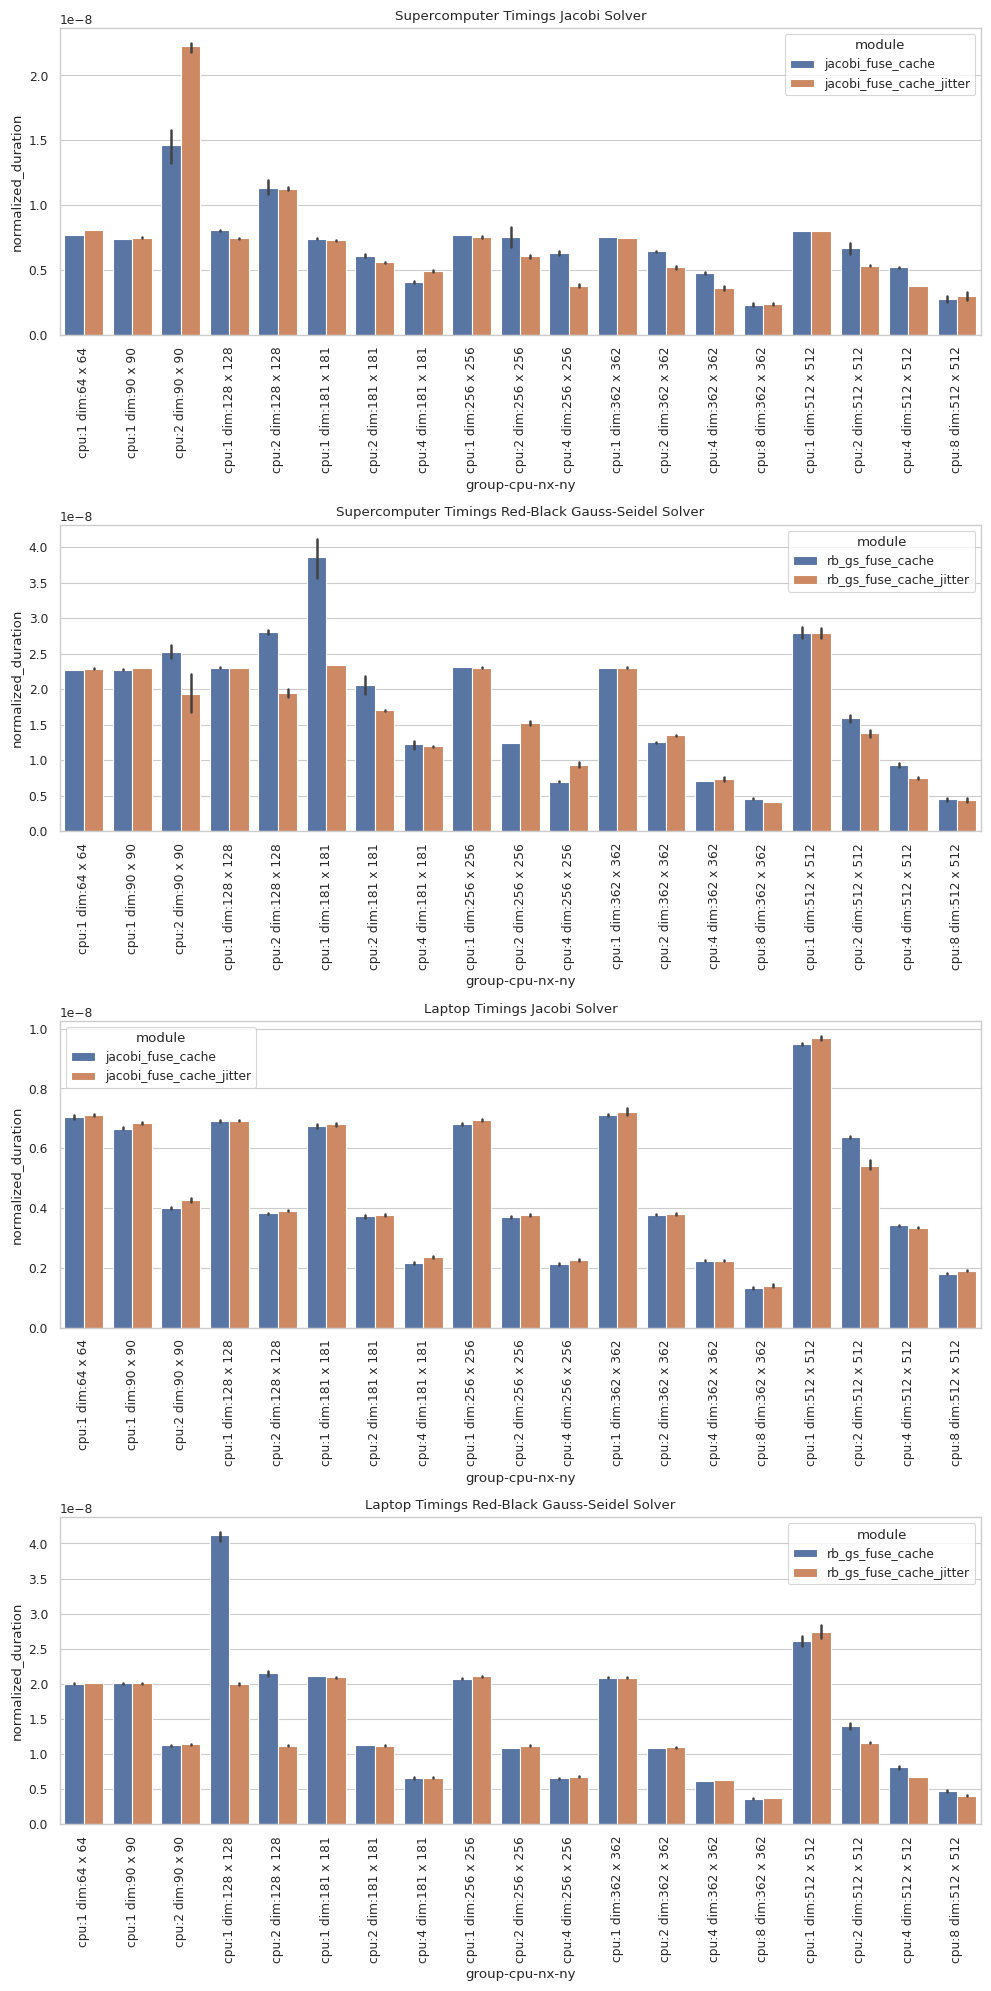

In [112]:
jitter_set_jacobi = joint_df[joint_df["module"].isin(["jacobi_fuse_cache", "jacobi_fuse_cache_jitter"])]
j_jacobi_sc = jitter_set_jacobi[jitter_set_jacobi["benchmark_name"].isin(["cpu_small_supercomputer", "cpu_medium_supercomputer"])].dropna(subset=["normalized_duration", "duration"]).sort_values(["nx", "ny", "cpu_count"])

jitter_set_rbgs = joint_df[joint_df["module"].isin(["rb_gs_fuse_cache", "rb_gs_fuse_cache_jitter"])]
j_rbgs_sc = jitter_set_rbgs[jitter_set_rbgs["benchmark_name"].isin(["cpu_small_supercomputer", "cpu_medium_supercomputer"])].dropna(subset=["normalized_duration", "duration"]).sort_values(["nx", "ny", "cpu_count"])

jitter_set_jacobi = joint_df[joint_df["module"].isin(["jacobi_fuse_cache", "jacobi_fuse_cache_jitter"])]
j_jacobi_lt = jitter_set_jacobi[jitter_set_jacobi["benchmark_name"].isin(["cpu_small_laptop", "cpu_medium_laptop"])].dropna(subset=["normalized_duration", "duration"]).sort_values(["nx", "ny", "cpu_count"])

jitter_set_rbgs = joint_df[joint_df["module"].isin(["rb_gs_fuse_cache", "rb_gs_fuse_cache_jitter"])]
j_rbgs_lt = jitter_set_rbgs[jitter_set_rbgs["benchmark_name"].isin(["cpu_small_laptop", "cpu_medium_laptop"])].dropna(subset=["normalized_duration", "duration"]).sort_values(["nx", "ny", "cpu_count"])

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(4, 1, figsize=(10, 20))

    # TODO idea: add ratio: jitter / not jitter and make heatmap plot underneath the bar plots

    # ax = plt.axes()
    ax[0].tick_params(axis='x', rotation=90)
    ax[0].set_title('Supercomputer Timings Jacobi Solver')
    sns.barplot(data=j_jacobi_sc, x="group-cpu-nx-ny", y="normalized_duration", hue="module", ax=ax[0])

    ax[1].tick_params(axis='x', rotation=90)
    ax[1].set_title('Supercomputer Timings Red-Black Gauss-Seidel Solver')
    sns.barplot(data=j_rbgs_sc, x="group-cpu-nx-ny", y="normalized_duration", hue="module", ax=ax[1])

    ax[2].tick_params(axis='x', rotation=90)
    ax[2].set_title('Laptop Timings Jacobi Solver')
    sns.barplot(data=j_jacobi_lt, x="group-cpu-nx-ny", y="normalized_duration", hue="module", ax=ax[2])

    ax[3].tick_params(axis='x', rotation=90)
    ax[3].set_title('Laptop Timings Red-Black Gauss-Seidel Solver')
    sns.barplot(data=j_rbgs_lt, x="group-cpu-nx-ny", y="normalized_duration", hue="module", ax=ax[3])

    plt.tight_layout()
    plt.show()
    write_fig("07_jitter_timings", fig)
